In [ ]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

In [ ]:
# time period for the data
end_date = date.today().strftime('%Y-%m-%d')
start_date = (date.today() - timedelta(days = 365)).strftime('%Y-%m-%d')

In [ ]:
# list of stock tickers to download
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ZOMATO.NS']
data = yf.download(tickers, start = start_date, end = end_date)

[*********************100%***********************]  5 of 5 completed


In [ ]:
data.head()

Price                        Adj Close                                         \
Ticker                     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date                                                                            
2023-11-09 00:00:00+00:00  1465.636108  1340.277100  1147.459595  3299.898193   
2023-11-10 00:00:00+00:00  1471.407227  1334.476440  1149.619751  3286.096924   
2023-11-13 00:00:00+00:00  1468.743652  1339.058472  1149.470947  3284.224121   
2023-11-15 00:00:00+00:00  1484.133545  1375.080566  1170.254272  3355.940918   
2023-11-16 00:00:00+00:00  1488.030273  1408.616821  1172.364868  3448.162109   

Price                                        Close                            \
Ticker                      ZOMATO.NS  HDFCBANK.NS      INFY.NS  RELIANCE.NS   
Date                                                                           
2023-11-09 00:00:00+00:00  121.849998  1485.650024  1374.800049  1155.275024   
2023-11-10 00:00:00+00:00  121.300003  1491.500000  1368.849976  1157.449951   
2023-11-13 00:00:00+00:00  122.199997  1488.800049  1373.550049  1157.300049   
2023-11-15 00:00:00+00:00  120.250000  1504.400024  1410.500000  1178.224976   
2023-11-16 00:00:00+00:00  121.849998  1508.349976  1444.900024  1180.349976   

Price                                               ...         Open  \
Ticker                          TCS.NS   ZOMATO.NS  ...  HDFCBANK.NS   
Date                                                ...                
2023-11-09 00:00:00+00:00  3347.449951  121.849998  ...  1486.000000   
2023-11-10 00:00:00+00:00  3333.449951  121.300003  ...  1480.099976   
2023-11-13 00:00:00+00:00  3331.550049  122.199997  ...  1492.099976   
2023-11-15 00:00:00+00:00  3404.300049  120.250000  ...  1504.099976   
2023-11-16 00:00:00+00:00  3497.850098  121.849998  ...  1509.699951   

Price                                                                         \
Ticker                         INFY.NS  RELIANCE.NS       TCS.NS   ZOMATO.NS   
Date                                                                           
2023-11-09 00:00:00+00:00  1395.900024  1167.925049  3390.100098  125.250000   
2023-11-10 00:00:00+00:00  1369.949951  1152.775024  3338.000000  122.000000   
2023-11-13 00:00:00+00:00  1379.849976  1161.449951  3356.000000  122.650002   
2023-11-15 00:00:00+00:00  1399.000000  1170.000000  3383.100098  123.300003   
2023-11-16 00:00:00+00:00  1416.099976  1175.550049  3430.050049  120.900002   

Price                          Volume                                          
Ticker                    HDFCBANK.NS  INFY.NS RELIANCE.NS   TCS.NS ZOMATO.NS  
Date                                                                           
2023-11-09 00:00:00+00:00    11058370  5498051    14513610  2112352  50307832  
2023-11-10 00:00:00+00:00     7007593  2943649     7734954  1338557  43388163  
2023-11-13 00:00:00+00:00    10302957  3462092     3854810  1030990  28348143  
2023-11-15 00:00:00+00:00    20622730  8551860    12220648  2059802  60088818  
2023-11-16 00:00:00+00:00    14856919  6673907    13134910  3951984  36895083  

[5 rows x 30 columns]

In [ ]:
# reset index to bring Date into the columns for the melt function
data = data.reset_index()
data['Date'] = data['Date'].dt.date
data.head(2)

Price         Date    Adj Close                                        \
Ticker              HDFCBANK.NS     INFY.NS  RELIANCE.NS       TCS.NS   
0       2023-11-09  1465.636108  1340.27710  1147.459595  3299.898193   
1       2023-11-10  1471.407227  1334.47644  1149.619751  3286.096924   

Price                     Close                                         ...  \
Ticker   ZOMATO.NS  HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS  ...   
0       121.849998  1485.650024  1374.800049  1155.275024  3347.449951  ...   
1       121.300003  1491.500000  1368.849976  1157.449951  3333.449951  ...   

Price          Open                                                   \
Ticker  HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS ZOMATO.NS   
0       1486.000000  1395.900024  1167.925049  3390.100098    125.25   
1       1480.099976  1369.949951  1152.775024  3338.000000    122.00   

Price       Volume                                          
Ticker HDFCBANK.NS  INFY.NS RELIANCE.NS   TCS.NS ZOMATO.NS  
0         11058370  5498051    14513610  2112352  50307832  
1          7007593  2943649     7734954  1338557  43388163  

[2 rows x 31 columns]

In [ ]:
data.to_csv('stock_data.csv')

In [ ]:
data.columns = [f"{i}_{j}" if j else i for i, j in data.columns]
data.columns

Index(['Date', 'Adj Close_HDFCBANK.NS', 'Adj Close_INFY.NS',
       'Adj Close_RELIANCE.NS', 'Adj Close_TCS.NS', 'Adj Close_ZOMATO.NS',
       'Close_HDFCBANK.NS', 'Close_INFY.NS', 'Close_RELIANCE.NS',
       'Close_TCS.NS', 'Close_ZOMATO.NS', 'High_HDFCBANK.NS', 'High_INFY.NS',
       'High_RELIANCE.NS', 'High_TCS.NS', 'High_ZOMATO.NS', 'Low_HDFCBANK.NS',
       'Low_INFY.NS', 'Low_RELIANCE.NS', 'Low_TCS.NS', 'Low_ZOMATO.NS',
       'Open_HDFCBANK.NS', 'Open_INFY.NS', 'Open_RELIANCE.NS', 'Open_TCS.NS',
       'Open_ZOMATO.NS', 'Volume_HDFCBANK.NS', 'Volume_INFY.NS',
       'Volume_RELIANCE.NS', 'Volume_TCS.NS', 'Volume_ZOMATO.NS'],
      dtype='object')

In [ ]:
# melt the DataFrame to make it long format where each row is a unique combination of Date, Ticker and Attributes
data_melted = data.melt(id_vars=['Date'], var_name='Attribute_Ticker', value_name = 'value')
data_melted.head(2)

,Date,Attribute_Ticker,value
0,2023-11-09,Adj Close_HDFCBANK.NS,1465.636108
1,2023-11-10,Adj Close_HDFCBANK.NS,1471.407227


In [ ]:
data_melted[['Attribute', 'Ticker']] = data_melted['Attribute_Ticker'].str.rsplit("_", n= 1, expand = True)
data_melted.head(2)

,Date,Attribute_Ticker,value,Attribute,Ticker
0,2023-11-09,Adj Close_HDFCBANK.NS,1465.636108,Adj Close,HDFCBANK.NS
1,2023-11-10,Adj Close_HDFCBANK.NS,1471.407227,Adj Close,HDFCBANK.NS


In [ ]:
data_melted = data_melted.drop(columns=['Attribute_Ticker'])
data_melted.head(2)

,Date,value,Attribute,Ticker
0,2023-11-09,1465.636108,Adj Close,HDFCBANK.NS
1,2023-11-10,1471.407227,Adj Close,HDFCBANK.NS


In [ ]:
# pivot the melted DataFrame to have the attributes (Open, High', 'Low', etc) as columns
data_pivoted = data_melted.pivot_table(index = ['Date', 'Ticker'], columns = 'Attribute', values = 'value', aggfunc = 'first')
data_pivoted.head()

Attribute                 Adj Close        Close         High          Low  \
Date       Ticker                                                            
2023-11-09 HDFCBANK.NS  1465.636108  1485.650024  1492.599976  1483.500000   
           INFY.NS      1340.277100  1374.800049  1397.500000  1370.050049   
           RELIANCE.NS  1147.459595  1155.275024  1167.949951  1152.099976   
           TCS.NS       3299.898193  3347.449951  3391.500000  3342.050049   
           ZOMATO.NS     121.849998   121.849998   125.550003   121.349998   

Attribute                      Open      Volume  
Date       Ticker                                
2023-11-09 HDFCBANK.NS  1486.000000  11058370.0  
           INFY.NS      1395.900024   5498051.0  
           RELIANCE.NS  1167.925049  14513610.0  
           TCS.NS       3390.100098   2112352.0  
           ZOMATO.NS     125.250000  50307832.0

In [ ]:
# reset the index to turn multi_index into columns
stock_data = data_pivoted.reset_index()

In [ ]:
stock_data.head()

Attribute,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2023-11-09,HDFCBANK.NS,1465.636108,1485.650024,1492.599976,1483.500000,1486.000000,11058370.0
1,2023-11-09,INFY.NS,1340.277100,1374.800049,1397.500000,1370.050049,1395.900024,5498051.0
2,2023-11-09,RELIANCE.NS,1147.459595,1155.275024,1167.949951,1152.099976,1167.925049,14513610.0
3,2023-11-09,TCS.NS,3299.898193,3347.449951,3391.500000,3342.050049,3390.100098,2112352.0
4,2023-11-09,ZOMATO.NS,121.849998,121.849998,125.550003,121.349998,125.250000,50307832.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data.set_index('Date', inplace = True)

In [ ]:
stock_data.reset_index(inplace = True)

In [ ]:
stock_data.head()

Attribute,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2023-11-09,HDFCBANK.NS,1465.636108,1485.650024,1492.599976,1483.500000,1486.000000,11058370.0
1,2023-11-09,INFY.NS,1340.277100,1374.800049,1397.500000,1370.050049,1395.900024,5498051.0
2,2023-11-09,RELIANCE.NS,1147.459595,1155.275024,1167.949951,1152.099976,1167.925049,14513610.0
3,2023-11-09,TCS.NS,3299.898193,3347.449951,3391.500000,3342.050049,3390.100098,2112352.0
4,2023-11-09,ZOMATO.NS,121.849998,121.849998,125.550003,121.349998,125.250000,50307832.0


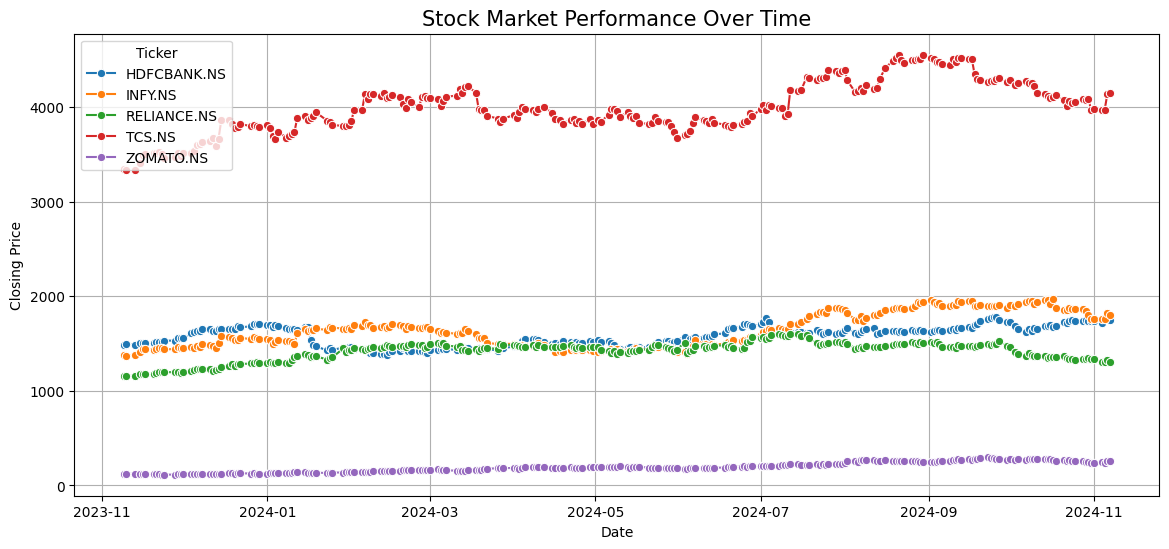

In [ ]:
# stock market performance of these companies over time in market
plt.figure(figsize = (14, 6))
sns.lineplot(data = stock_data, x = 'Date', y = 'Close', hue = 'Ticker', marker = 'o')
plt.title('Stock Market Performance Over Time', fontsize = 15)
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title = 'Ticker', loc = 'upper left')
plt.grid()
plt.show()

In [ ]:
stock_data.head()

Attribute,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2023-11-09,HDFCBANK.NS,1465.636108,1485.650024,1492.599976,1483.500000,1486.000000,11058370.0
1,2023-11-09,INFY.NS,1340.277100,1374.800049,1397.500000,1370.050049,1395.900024,5498051.0
2,2023-11-09,RELIANCE.NS,1147.459595,1155.275024,1167.949951,1152.099976,1167.925049,14513610.0
3,2023-11-09,TCS.NS,3299.898193,3347.449951,3391.500000,3342.050049,3390.100098,2112352.0
4,2023-11-09,ZOMATO.NS,121.849998,121.849998,125.550003,121.349998,125.250000,50307832.0


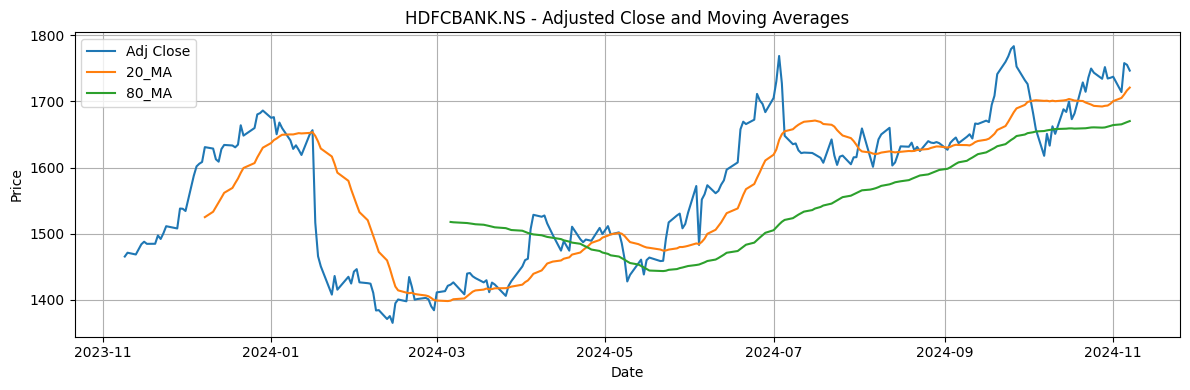

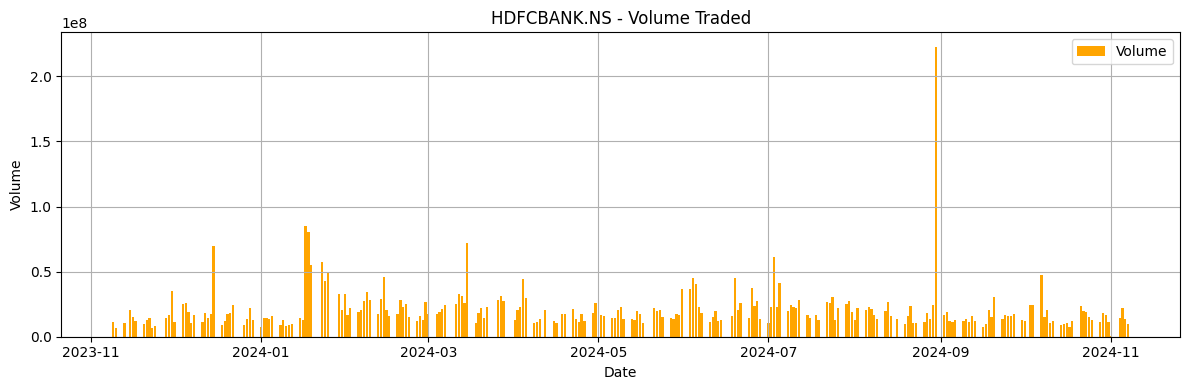

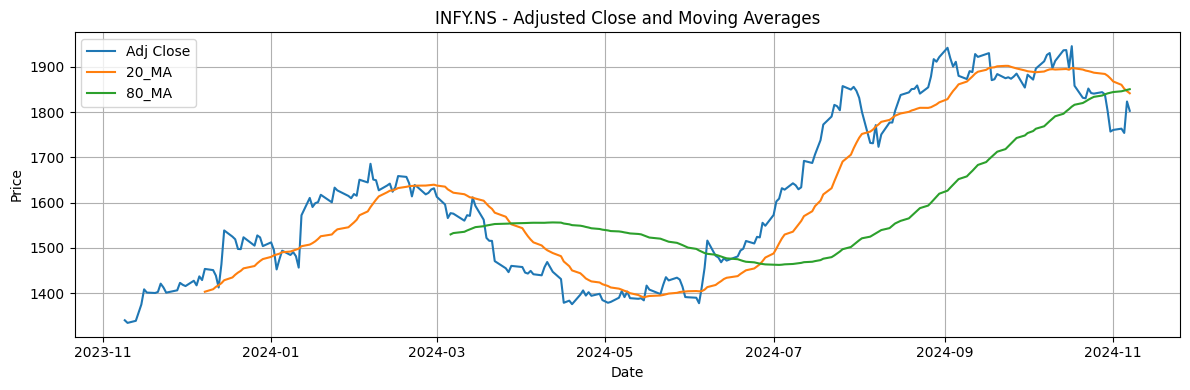

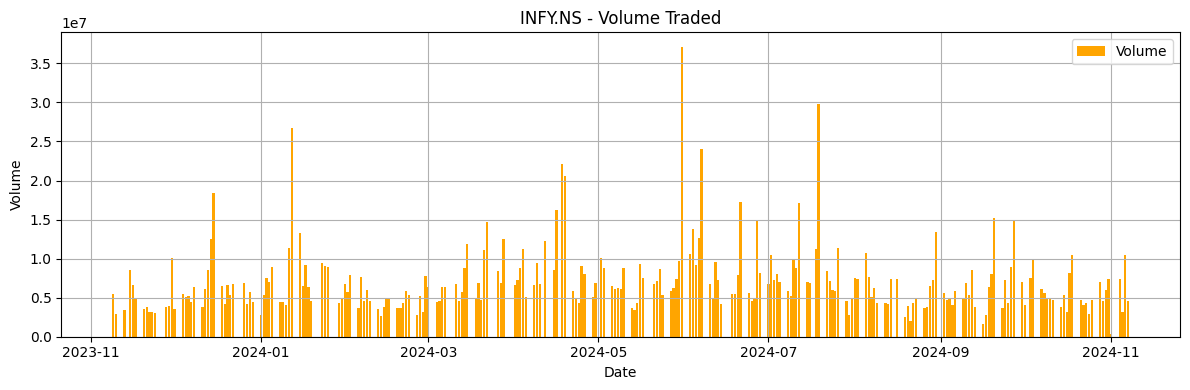

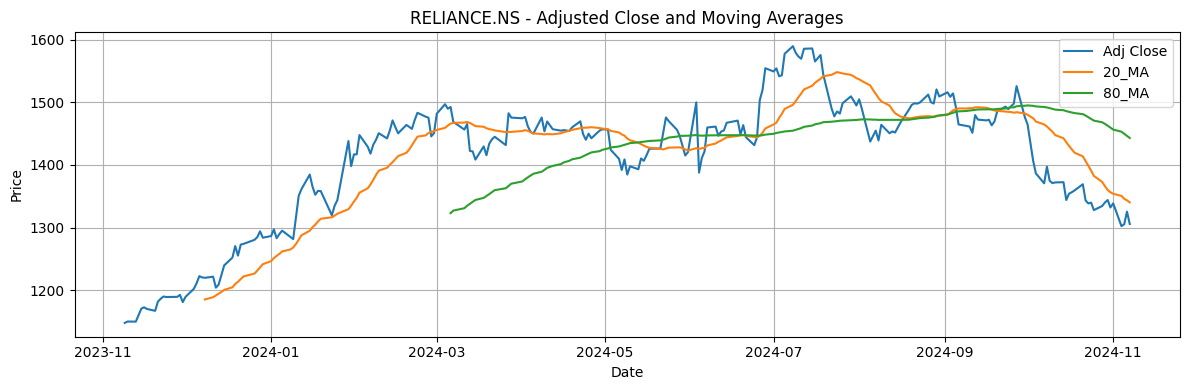

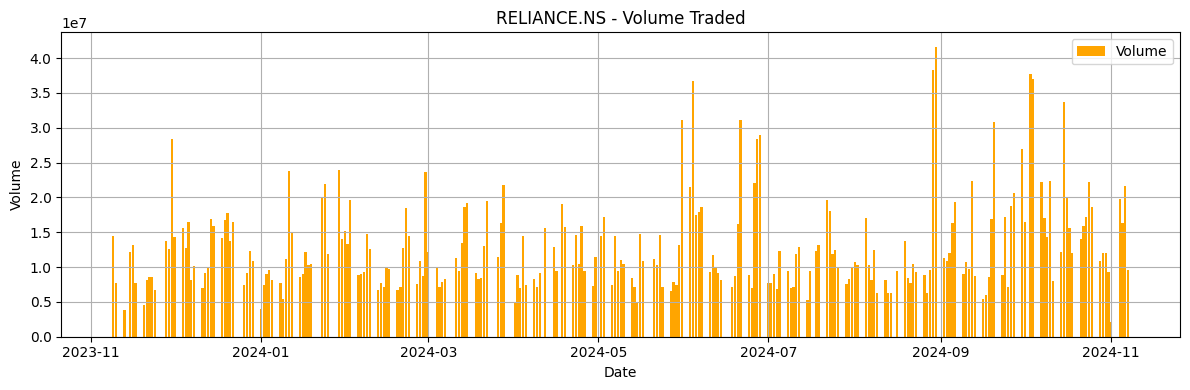

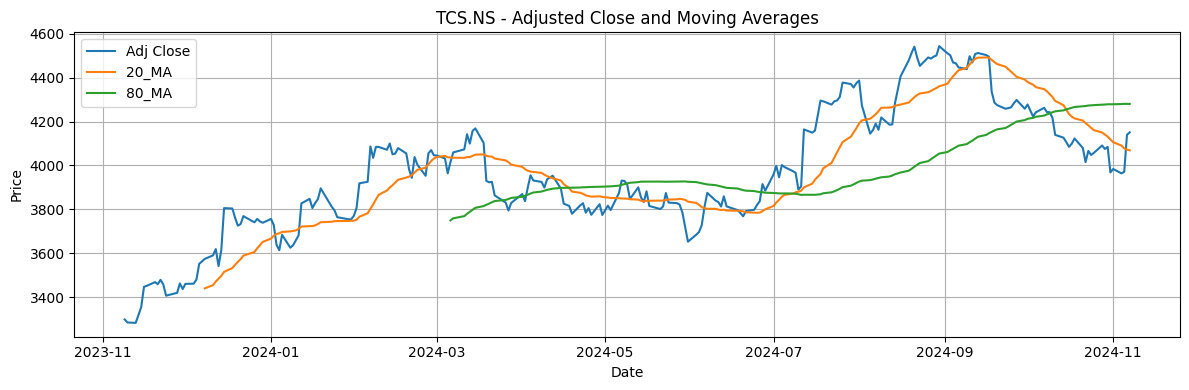

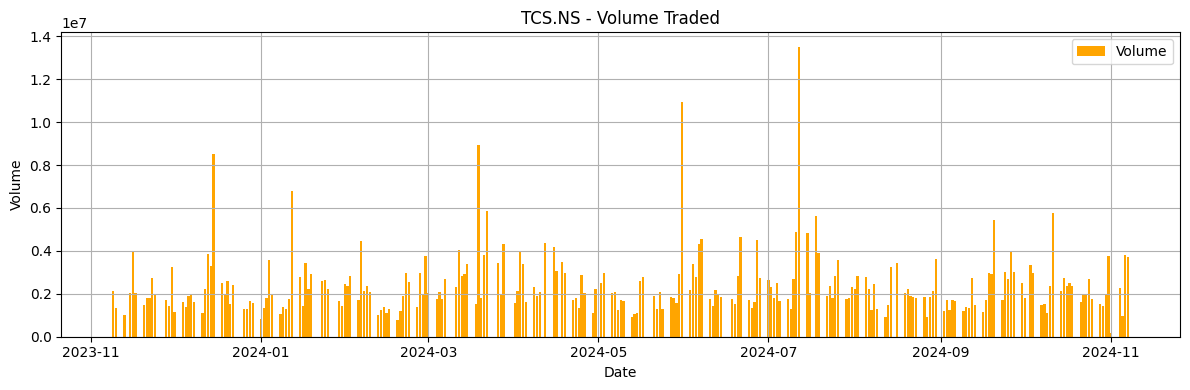

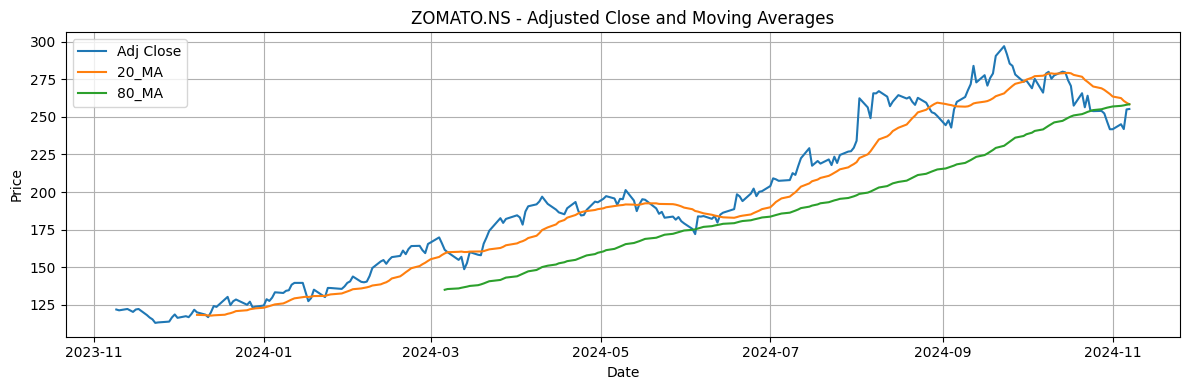

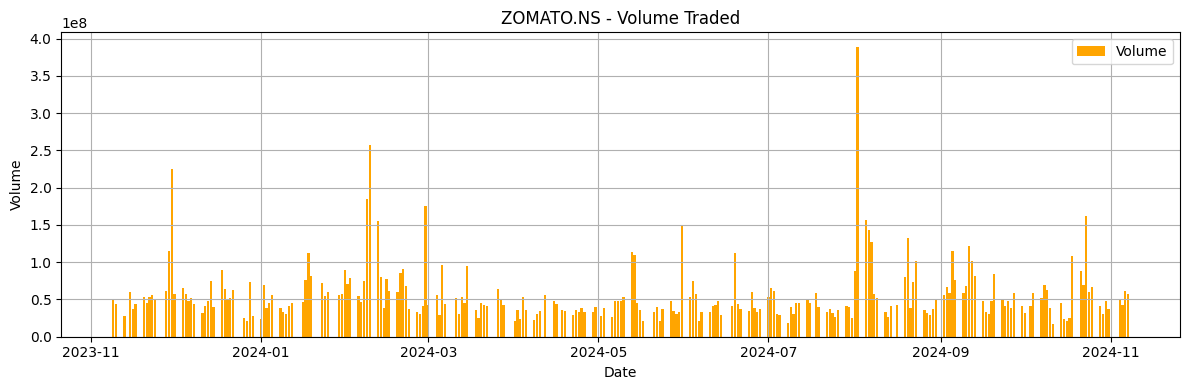

In [ ]:
# compute the 50_day and 200_day moving averages and plotting these along with the adjusted close prices
short_window = 20
long_window = 80

stock_data.set_index('Date', inplace = True)
unqiue_tickers = stock_data['Ticker'].unique()
for ticker in unqiue_tickers:
  ticker_data = stock_data[stock_data['Ticker'] == ticker].copy()
  ticker_data['20_MA'] = ticker_data['Adj Close'].rolling(window = short_window).mean()
  ticker_data['80_MA'] = ticker_data['Adj Close'].rolling(window = long_window).mean()

  plt.figure(figsize = (12, 4))
  plt.plot(ticker_data.index, ticker_data['Adj Close'], label = 'Adj Close')
  plt.plot(ticker_data.index, ticker_data['20_MA'], label = '20_MA')
  plt.plot(ticker_data.index, ticker_data['80_MA'], label = '80_MA')
  plt.title(f'{ticker} - Adjusted Close and Moving Averages')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.show()

  plt.figure(figsize = (12, 4))
  plt.bar(ticker_data.index, ticker_data['Volume'], label = 'Volume', color = 'orange')
  plt.title(f'{ticker} - Volume Traded')
  plt.xlabel('Date')
  plt.ylabel('Volume')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.show()


In [ ]:
stock_data.head()

Attribute,Ticker,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,,
2023-11-09,HDFCBANK.NS,1465.636108,1485.650024,1492.599976,1483.500000,1486.000000,11058370.0
2023-11-09,INFY.NS,1340.277100,1374.800049,1397.500000,1370.050049,1395.900024,5498051.0
2023-11-09,RELIANCE.NS,1147.459595,1155.275024,1167.949951,1152.099976,1167.925049,14513610.0
2023-11-09,TCS.NS,3299.898193,3347.449951,3391.500000,3342.050049,3390.100098,2112352.0
2023-11-09,ZOMATO.NS,121.849998,121.849998,125.550003,121.349998,125.250000,50307832.0


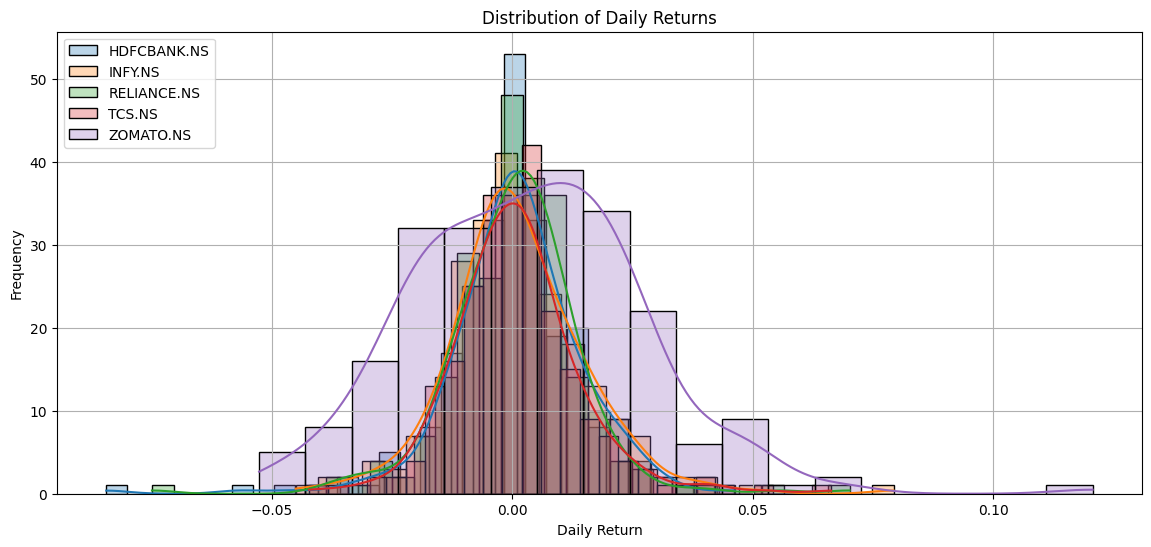

In [ ]:
# Distribution of Daily returns
stock_data['Daily Return'] = stock_data.groupby('Ticker')['Adj Close'].pct_change()
plt.figure(figsize = (14, 6))

for ticker in unqiue_tickers:
  ticker_data = stock_data[stock_data['Ticker'] == ticker]
  sns.histplot(ticker_data['Daily Return'].dropna(), kde = True, label = ticker, alpha = 0.3)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()


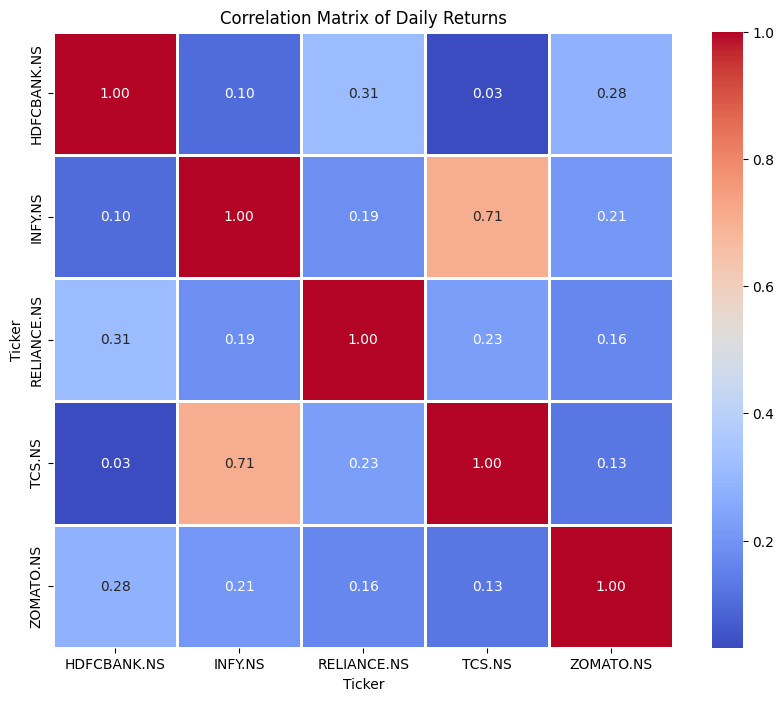

In [ ]:
daily_returns =stock_data.pivot_table(index = 'Date', columns = 'Ticker', values = 'Daily Return', aggfunc = 'mean')
corr_matrix = daily_returns.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', linewidth = .8, fmt = '.2f', annot_kws = {'size': 10})
plt.title('Correlation Matrix of Daily Returns')
plt.show()

In [ ]:
# Portfolio Optimization

In [ ]:
# calculate the expected returns and volatility for each stock
import numpy as np
expected_returns = daily_returns.mean() * 252
volatility = daily_returns.std()*np.sqrt(252)

stocks_stats = pd.DataFrame({'Expected Return': expected_returns, 'Volatility': volatility})
stocks_stats

,Expected Return,Volatility
Ticker,,
HDFCBANK.NS,0.205742,0.220969
INFY.NS,0.333227,0.232514
RELIANCE.NS,0.157907,0.221657
TCS.NS,0.259128,0.211312
ZOMATO.NS,0.835034,0.377770


In [ ]:
# generate random portfolios and plot the efficient frontier

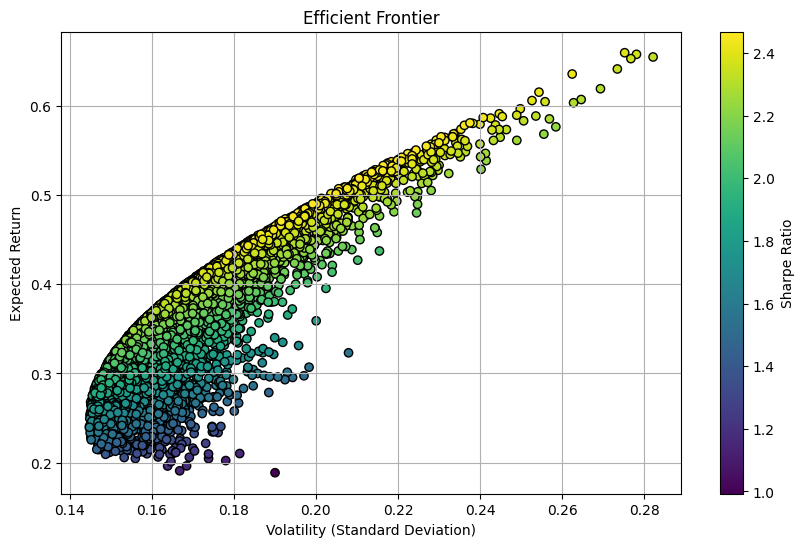

In [ ]:
# function to calculate portfolio performance
def portfolio_performance(weights, mean_returns, cov_matrix):
  portfolio_return = np.dot(weights, mean_returns)
  portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  return portfolio_return, portfolio_volatility

# number of portfolios to simulate (weightage assigned)
num_portfolios = 10000

# arrays to store the results
results = np.zeros((3, num_portfolios))

# annualized covariance matrix
cov_matrix = daily_returns.cov() * 252

np.random.seed(13)

for i in range(num_portfolios):
  weights = np.random.random(len(unqiue_tickers))
  weights /= np.sum(weights)

  portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)
  results[0, i] = portfolio_return
  results[1, i] = portfolio_volatility
  results[2, i] = portfolio_return / portfolio_volatility

plt.figure(figsize = (10, 6))
plt.scatter(results[1, :], results[0, :], c = results[2, :], cmap = 'viridis', edgecolors = 'k')
plt.title('Efficient Frontier')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.colorbar(label = 'Sharpe Ratio')
plt.grid()
plt.show()


In [ ]:
# portfolio with max sharpe ratio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]

max_sharpe_return, max_sharpe_volatility

(0.5072246899095112, 0.20554039504836633)

In [ ]:
results

array([[0.37897724, 0.37101911, 0.40035025, ..., 0.28084417, 0.46959896,
        0.41886474],
       [0.16501355, 0.16234031, 0.18381772, ..., 0.15158955, 0.20752816,
        0.18349145],
       [2.29664312, 2.28544054, 2.17797415, ..., 1.85266184, 2.26282038,
        2.282748  ]])

In [ ]:
max_sharpe_weights = np.zeros(len(unqiue_tickers))

for i in range(num_portfolios):
  weights = np.random.random(len(unqiue_tickers))
  weights /= np.sum(weights)
  portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)

  if results[2, i] == max_sharpe_ratio:
    max_sharpe_weights = weights
    break

portfolio_weights_df = pd.DataFrame({'Ticker': unqiue_tickers, 'Weight': max_sharpe_weights})
portfolio_weights_df

,Ticker,Weight
0,HDFCBANK.NS,0.271607
1,INFY.NS,0.112242
2,RELIANCE.NS,0.189530
3,TCS.NS,0.168061
4,ZOMATO.NS,0.258561
